------

-------

# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

## Inicialización

In [1]:
# Cargar todas las librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st


## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames
users    = pd.read_csv('/datasets/megaline_users.csv')
calls    = pd.read_csv('/datasets/megaline_calls.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
plans    = pd.read_csv('/datasets/megaline_plans.csv')


## Preparar los datos

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [4]:
# Imprime una muestra de los datos para las tarifas
plans.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]


Ninguna columna tiene valores nulos (Non-Null Count = 2 en todas)

mb_per_month_included está en megabytes los planes los manejan en GB por lo que estaría bien agregar una columna con un recalculo en GB. Sin ese recálculo confunde que el número no sea cerrado ya que se tiene que dividir primero entre 1024. Mejor que cuadre con 15 y 30 para facilitar la lógica al hacer los cálculos. 



## Corregir datos

In [5]:
#No tiene duplicados ni NaN

## Enriquecer los datos

In [6]:
plans['gb_per_month_included'] = (plans['mb_per_month_included'] / 1024).astype(int)
plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,50,15360,500,20,10,0.03,0.03,surf,15
1,1000,30720,3000,70,7,0.01,0.01,ultimate,30


## Usuarios/as

In [7]:
# Imprime la información general/resumida sobre el DataFrame de usuarios

users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [8]:
# Imprime una muestra de datos para usuarios
print(users.isna().sum())
print()
users.sample(5)

user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
192,1192,Korey,Goodwin,36,"Buffalo-Cheektowaga, NY MSA",2018-10-02,surf,NaN
285,1285,Joesph,Barry,28,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-08-03,surf,NaN
15,1015,Beata,Carpenter,26,"Pittsburgh, PA MSA",2018-12-05,surf,NaN
457,1457,Janean,Lynch,47,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-17,surf,NaN
311,1311,Cherlyn,Saunders,69,"Memphis, TN-MS-AR MSA",2018-06-27,ultimate,NaN


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

Se podría pensar que los NaT son valores faltantes pero en este caso son los usuarios que aún no dan de baja ningún plan. La fecha marca el día que se dieron de baja. Cambiar los valores NaN por "activo" puede ser buena idea, pero igual combinar str en una columna con formato datetime puede dar error después. 

Fechas (reg_date y churn_date) están como object, para analizarlas mejor convertirlas a formato datetime.

En 'plan' puede ser útil ponerlo en minúsculas (.str.lower()) para evitar inconsistencias.

### Corregir los datos

In [9]:
users['reg_date'] = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'])

### Enriquecer los datos

In [10]:
users['plan'] = users['plan'].str.lower()

## Llamadas

In [11]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas

calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [12]:
# Imprime una muestra de datos para las llamadas

calls.sample(5)

,id,user_id,call_date,duration
42674,1156_279,1156,2018-05-18,0.00
62456,1224_92,1224,2018-09-05,6.41
81132,1292_84,1292,2018-09-26,11.74
66555,1240_413,1240,2018-12-14,5.51
124317,1439_185,1439,2018-10-20,4.07


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

(id) está como object porque esta en formato snake_case. Es diferente al user_id que no tiene guión bajo. 

(call_date) está como object, hay que convertir a datetime para agrupar por mes.

Duración en decimales en (float). El negocio cobra redondeando cada llamada al minuto superior (ceil), por lo que no tiene caso que se vea como float. 

Tambien hay que eliminar las llamadas en 0:00 ya que equivale a NaN.

Podemos crear una columna extra con el ceil para que podamos facilitar la lógica en los calcúlos. 


### Corregir los datos

In [13]:
calls['call_date'] = pd.to_datetime(calls['call_date'])
calls = calls[calls['duration'] > 0]

### Enriquecer los datos

In [14]:
calls['duration_ceil'] = np.ceil(calls['duration']).astype(int)

## Mensajes

In [15]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes

messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [16]:
# Imprime una muestra de datos para los mensajes
messages.sample(5)


,id,user_id,message_date
38307,1252_67,1252,2018-10-13
73634,1472_225,1472,2018-05-10
8976,1066_149,1066,2018-06-16
31357,1195_224,1195,2018-12-04
7699,1060_35,1060,2018-08-29


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]


No hay NaN.

message_date es object: lo ideal es convertirla a datetime para agrupar por mes.


### Corregir los datos

In [17]:
messages['message_date'] = pd.to_datetime(messages['message_date'])

### Enriquecer los datos

In [18]:
#####

## Internet

In [19]:
# Imprime la información general/resumida sobre el DataFrame de internet
internet.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [20]:
# Imprime una muestra de datos para el tráfico de internet
internet.sample(5)


,id,user_id,session_date,mb_used
68623,1320_287,1320,2018-11-11,169.64
18976,1085_50,1085,2018-11-12,840.74
53842,1243_144,1243,2018-10-28,657.25
50603,1226_84,1226,2018-09-10,112.58
17014,1077_134,1077,2018-03-28,1123.81




session_date está como object: conviene convertirla a datetime para agrupar por mes, porque el cobro es por mes.

Sesiones con mb_used = 0.00. Probablemente convenga dejarlas, porque reflejan actividad aunque no se haya consumido datos (no generan costo extra).

El plan define límites en MB por mes, pero el cobro extra se hace en GB redondeados hacia arriba. Entonces primero sumaremos los MB de cada mes y luego aplicaremos np.ceil(total_mb/1024).

### Corregir los datos

In [21]:
internet['session_date'] = pd.to_datetime(internet['session_date'])

### Enriquecer los datos

In [22]:
internet['gb_used'] = internet['mb_used'] / 1024

## Estudiar las condiciones de las tarifas

In [23]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
plans


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,50,15360,500,20,10,0.03,0.03,surf,15
1,1000,30720,3000,70,7,0.01,0.01,ultimate,30


Surf

Pago mensual: $20

Incluye: 500 min, 50 SMS, 15 GB (15,360 MB)

Excedentes: 0.03/min, 0.03/SMS, 10/GB

Ultimate

Pago mensual: $70

Incluye: 3000 min, 1000 SMS, 30 GB (30,720 MB)

Excedentes: 0.01/min, 0.01/SMS, 7/GB

In [24]:
## Agregar datos por usuario

#[Ahora que los datos están limpios, agrega los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. Esto facilitará mucho el análisis posterior.]

In [25]:
calls['month'] = calls['call_date'].dt.to_period('M')
messages['month'] = messages['message_date'].dt.to_period('M')
internet['month'] = internet['session_date'].dt.to_period('M')

In [26]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
calls_per_month = (
    calls.groupby(['user_id', 'month'], as_index=False)
    .agg(num_llamadas=('id','count'))
)

calls_per_month.head()

,user_id,month,num_llamadas
0,1000,2018-12,16
1,1001,2018-08,22
2,1001,2018-09,38
3,1001,2018-10,47
4,1001,2018-11,49


In [27]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.

minutes_per_month = (
    calls.groupby(['user_id','month'], as_index=False)
    .agg(total_minutos=('duration_ceil','sum'))
)

minutes_per_month.head()


,user_id,month,total_minutos
0,1000,2018-12,124
1,1001,2018-08,182
2,1001,2018-09,315
3,1001,2018-10,393
4,1001,2018-11,426


In [28]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
sms_per_month = (
    messages.groupby(['user_id','month'], as_index=False)
    .agg(num_sms=('id','count'))
)

sms_per_month.head()

,user_id,month,num_sms
0,1000,2018-12,11
1,1001,2018-08,30
2,1001,2018-09,44
3,1001,2018-10,53
4,1001,2018-11,36


In [29]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.

internet_per_month = (
    internet.groupby(['user_id','month'], as_index=False)
    .agg(total_mb=('mb_used','sum'))
)
internet_per_month.head()

,user_id,month,total_mb
0,1000,2018-12,1901.47
1,1001,2018-08,6919.15
2,1001,2018-09,13314.82
3,1001,2018-10,22330.49
4,1001,2018-11,18504.30


In [30]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month


calls_data = (
    calls.groupby(['user_id','month'], as_index=False)
    .agg(num_llamadas=('id','count'),
         total_minutos=('duration_ceil','sum'))
)




merged = calls_data.merge(
    sms_per_month, on=['user_id','month'], how='outer'
)



merged = merged.merge(
    internet_per_month, on=['user_id','month'], how='outer'
)

#merged.head()


merged = merged.fillna(0)

merged['num_llamadas'] = merged['num_llamadas'].astype(int)
merged['total_minutos'] = merged['total_minutos'].astype(int)
merged['num_sms'] = merged['num_sms'].astype(int)

merged.head()

,user_id,month,num_llamadas,total_minutos,num_sms,total_mb
0,1000,2018-12,16,124,11,1901.47
1,1001,2018-08,22,182,30,6919.15
2,1001,2018-09,38,315,44,13314.82
3,1001,2018-10,47,393,53,22330.49
4,1001,2018-11,49,426,36,18504.30


In [31]:
# Añade la información de la tarifa

users['plan'] = users['plan'].str.lower().str.strip()
plans['plan_name'] = plans['plan_name'].str.lower().str.strip()


plans['gb_per_month_included'] = (plans['mb_per_month_included'] / 1024).astype(int)




merged = merged.fillna({'num_llamadas':0, 'total_minutos':0, 'num_sms':0, 'total_mb':0.0})
merged[['num_llamadas','total_minutos','num_sms']] = merged[['num_llamadas','total_minutos','num_sms']].astype(int)




usage = merged.merge(
    users[['user_id','plan','city']], on='user_id', how='left'
)


usage = usage.merge(
    plans, left_on='plan', right_on='plan_name', how='left'
).drop(columns=['plan_name'])  


usage.head()

,user_id,month,num_llamadas,total_minutos,num_sms,total_mb,plan,city,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,gb_per_month_included
0,1000,2018-12,16,124,11,1901.47,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",1000,30720,3000,70,7,0.01,0.01,30
1,1001,2018-08,22,182,30,6919.15,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15360,500,20,10,0.03,0.03,15
2,1001,2018-09,38,315,44,13314.82,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15360,500,20,10,0.03,0.03,15
3,1001,2018-10,47,393,53,22330.49,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15360,500,20,10,0.03,0.03,15
4,1001,2018-11,49,426,36,18504.30,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15360,500,20,10,0.03,0.03,15


In [32]:
usage = usage.fillna({'total_minutos': 0, 'num_sms': 0, 'total_mb': 0})

mins_over = (usage['total_minutos'] - usage['minutes_included']).clip(lower=0)
sms_over  = (usage['num_sms'] - usage['messages_included']).clip(lower=0)
gb_over   = np.ceil((usage['total_mb'] - usage['mb_per_month_included']).clip(lower=0) / 1024).astype(int)

usage['monthly_revenue'] = (
    usage['usd_monthly_pay']
    + mins_over * usage['usd_per_minute']
    + sms_over  * usage['usd_per_message']
    + gb_over   * usage['usd_per_gb']
)

usage[['user_id','month','plan','monthly_revenue',]].head(10)


,user_id,month,plan,monthly_revenue
0,1000,2018-12,ultimate,70.00
1,1001,2018-08,surf,20.00
2,1001,2018-09,surf,20.00
3,1001,2018-10,surf,90.09
4,1001,2018-11,surf,60.00
5,1001,2018-12,surf,60.00
6,1002,2018-10,surf,20.00
7,1002,2018-11,surf,60.00
8,1002,2018-12,surf,20.00
9,1003,2018-12,surf,158.12


## Estudia el comportamiento de usuario

### Llamadas

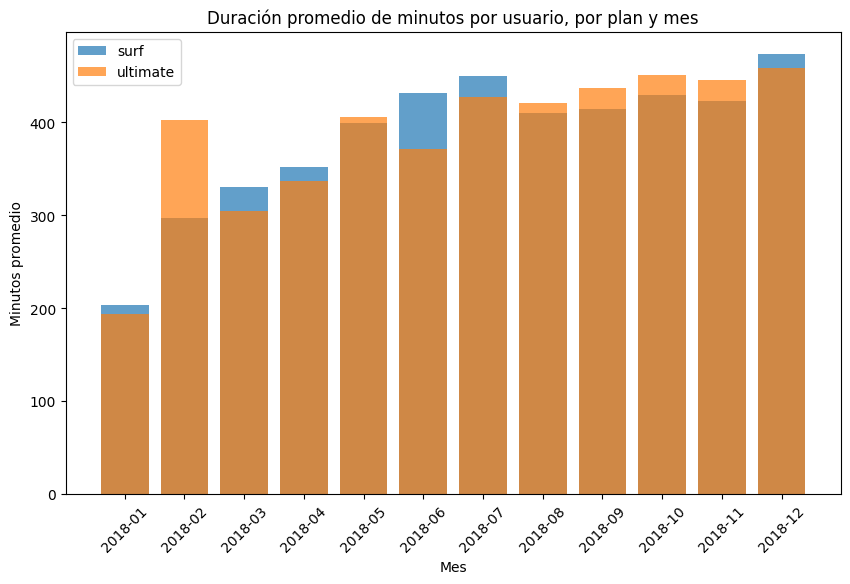

In [33]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

avg_minutes = (
    usage.groupby(['plan','month'], as_index=False)
    .agg(avg_minutos=('total_minutos','mean'))
)
avg_minutes.head()


plt.figure(figsize=(10,6))
for plan in avg_minutes['plan'].unique():
    subset = avg_minutes[avg_minutes['plan'] == plan]
    plt.bar(subset['month'].astype(str), subset['avg_minutos'], label=plan, alpha=0.7)



plt.xticks(rotation=45)
plt.title("Duración promedio de minutos por usuario, por plan y mes")
plt.xlabel("Mes")
plt.ylabel("Minutos promedio")
plt.legend()
plt.show()

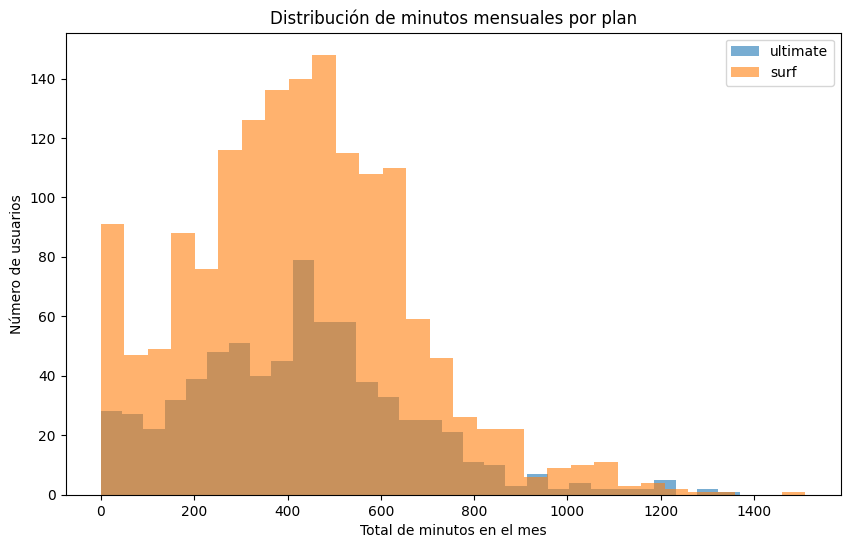

In [34]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

plt.figure(figsize=(10,6))

for plan in usage['plan'].unique():
    subset = usage[usage['plan'] == plan]
    plt.hist(subset['total_minutos'], bins=30, alpha=0.6, label=plan)

plt.title("Distribución de minutos mensuales por plan")
plt.xlabel("Total de minutos en el mes")
plt.ylabel("Número de usuarios")
plt.legend()
plt.show()

In [35]:
# Calcula la media y la varianza de la duración mensual de llamadas.
stats_minutes = (
    usage.groupby('plan', as_index=False)
    .agg(media_minutos=('total_minutos','mean'),
         varianza_minutos=('total_minutos','var'))
)

stats_minutes


,plan,media_minutos,varianza_minutos
0,surf,428.749523,54968.279461
1,ultimate,430.450000,57844.464812


<Figure size 1000x700 with 0 Axes>

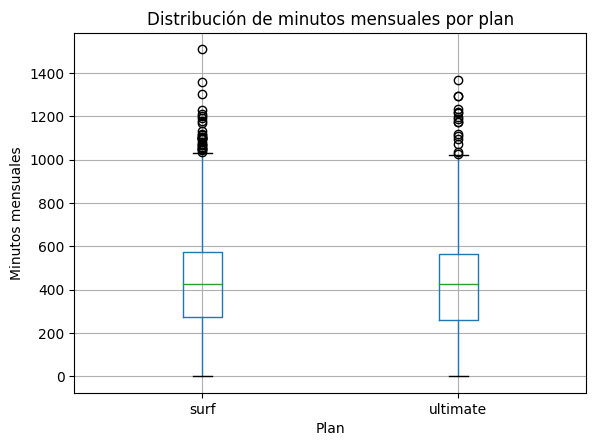

In [36]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

plt.figure(figsize=(10,7))


usage.boxplot(column='total_minutos', by='plan')

plt.title("Distribución de minutos mensuales por plan")
plt.suptitle("")
plt.xlabel("Plan")
plt.ylabel("Minutos mensuales")
plt.show()



1. Duración promedio de llamadas por mes y plan (barras)

-Tanto Surf como Ultimate se mantienen bastante similares en promedio.

-No hay un salto grande en el consumo de minutos entre planes.

-El patrón de crecimiento a lo largo del año es muy parecido en los dos planes.


2. Distribución de minutos mensuales por plan (histograma)

-Los usuarios de Surf se concentran en rangos más bajos-medios (200–600 min/mes).

-Los de Ultimate tienen una distribución un poco más larga, con algunos usuarios llegando a valores más altos, pero no masivos.

-Hay bastante superposición, ambos planes tienen muchos usuarios en el rango 300–600 min.


3. Diagrama de caja (boxplot)

-La mediana de minutos en los dos planes es muy parecida (400 min aprox).

-La dispersión es similar, los dos tienen muchos outliers arriba de 1000 minutos.

-Los bigotes (rango típico) tienen cifras parecidas en Surf y Ultimate.

### Mensajes

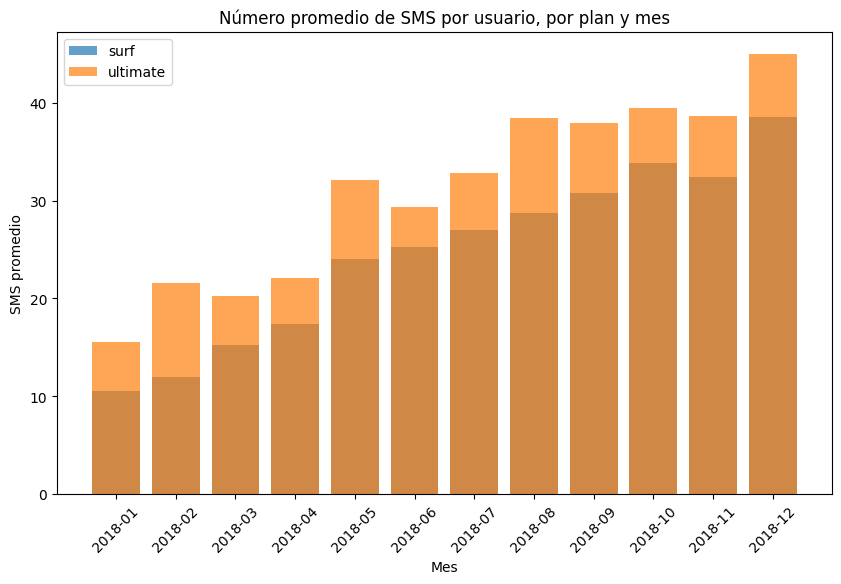

In [37]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan

avg_sms = (
    usage.groupby(['plan','month'], as_index=False)
    .agg(avg_sms=('num_sms','mean'))
)

avg_sms.head()

plt.figure(figsize=(10,6))
for plan in avg_sms['plan'].unique():
    subset = avg_sms[avg_sms['plan'] == plan]
    plt.bar(subset['month'].astype(str), subset['avg_sms'], label=plan, alpha=0.7)


plt.xticks(rotation=45)
plt.title("Número promedio de SMS por usuario, por plan y mes")
plt.xlabel("Mes")
plt.ylabel("SMS promedio")
plt.legend()
plt.show()

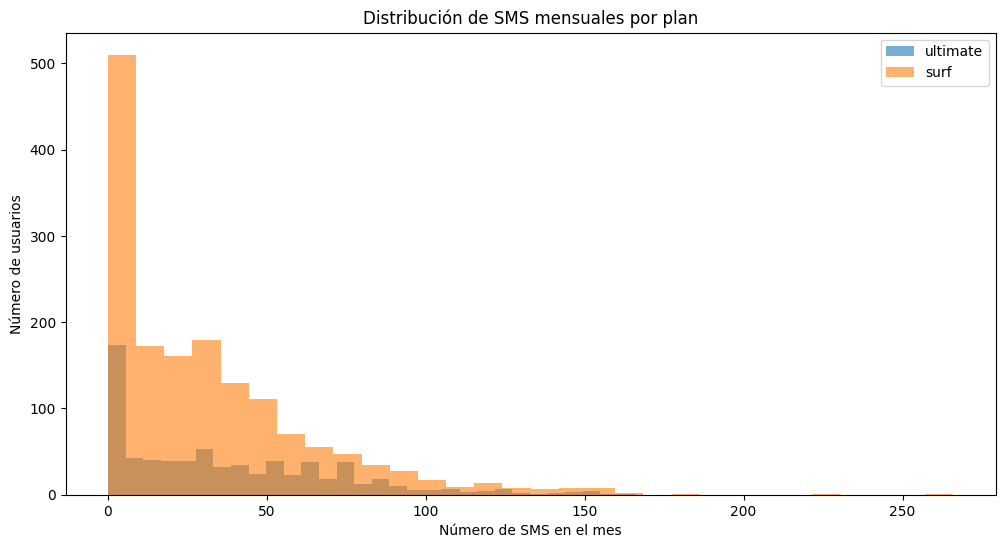

In [38]:

plt.figure(figsize=(12,6))

for plan in usage['plan'].unique():
    subset = usage[usage['plan'] == plan]
    plt.hist(subset['num_sms'], bins=30, alpha=0.6, label=plan)

plt.title("Distribución de SMS mensuales por plan")
plt.xlabel("Número de SMS en el mes")
plt.ylabel("Número de usuarios")
plt.legend()
plt.show()



<Figure size 800x600 with 0 Axes>

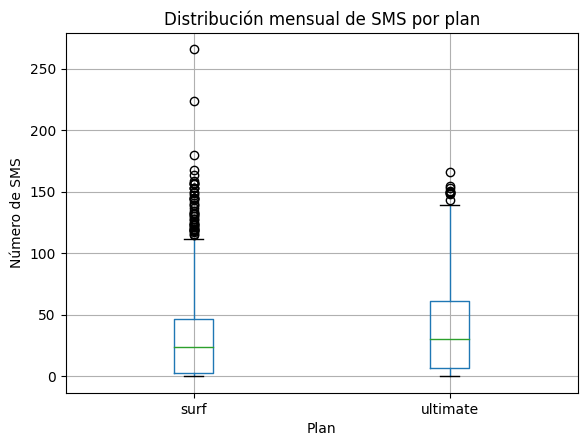

In [39]:
plt.figure(figsize=(8,6))
usage.boxplot(column='num_sms', by='plan')

plt.title("Distribución mensual de SMS por plan")
plt.suptitle("") 
plt.xlabel("Plan")
plt.ylabel("Número de SMS")
plt.show()



1. Promedio de SMS por usuario y mes (barras)

-Tanto en Surf como en Ultimate, el promedio de SMS enviados al mes aumenta a lo largo del año.

-Las diferencias entre planes son mínimas, Ultimate suele estar apenas por encima de Surf, pero no hay mucha diferencia.


2. Distribución de SMS (histograma)

-La mayoría de los usuarios en los planes envían muy pocos SMS al mes (la mayoría 0).

-Surf tiene muchos más usuarios inactivos o que no mandan SMS.

-Ultimate tiene menos usuarios que no mandan SMS, y proporcionalmente más usuarios que sí envían algunos (aunque tampoco son demasiados).

-La forma de la distribución es prácticamente la misma en los dos planes.


3. Diagrama de caja (boxplot)

-Las medianas son casi las mismas en los dos planes (20–30 SMS).

-La dispersión es amplia, con bastantes outliers (usuarios que envían >100 SMS al mes).

-Ni Surf ni Ultimate concentran claramente más heavy-users, los dos planes tienen muchos outliers.

### Internet

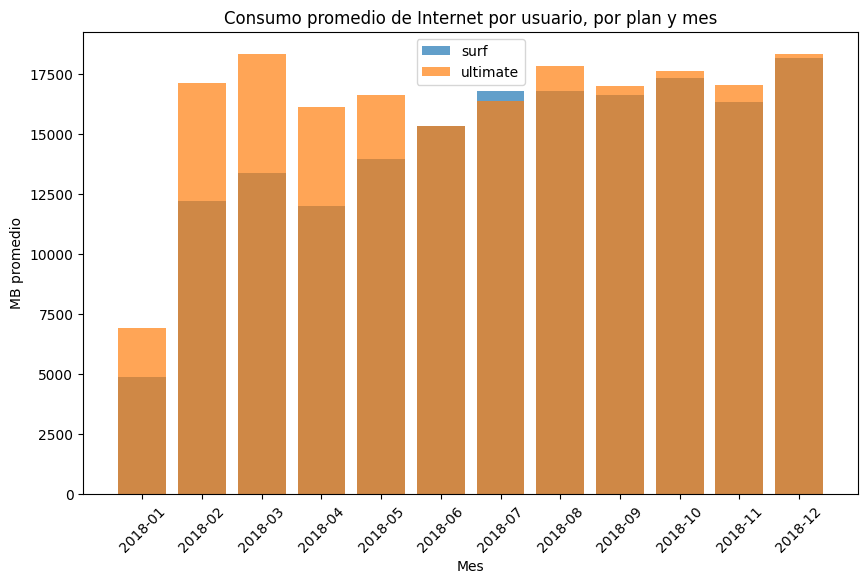

In [40]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
avg_internet = (
    usage.groupby(['plan','month'], as_index=False)
    .agg(avg_mb=('total_mb','mean'))
)



plt.figure(figsize=(10,6))
for plan in avg_internet['plan'].unique():
    subset = avg_internet[avg_internet['plan'] == plan]
    plt.bar(subset['month'].astype(str), subset['avg_mb'], label=plan, alpha=0.7)

plt.xticks(rotation=45)
plt.title("Consumo promedio de Internet por usuario, por plan y mes")
plt.xlabel("Mes")
plt.ylabel("MB promedio")
plt.legend()
plt.show()

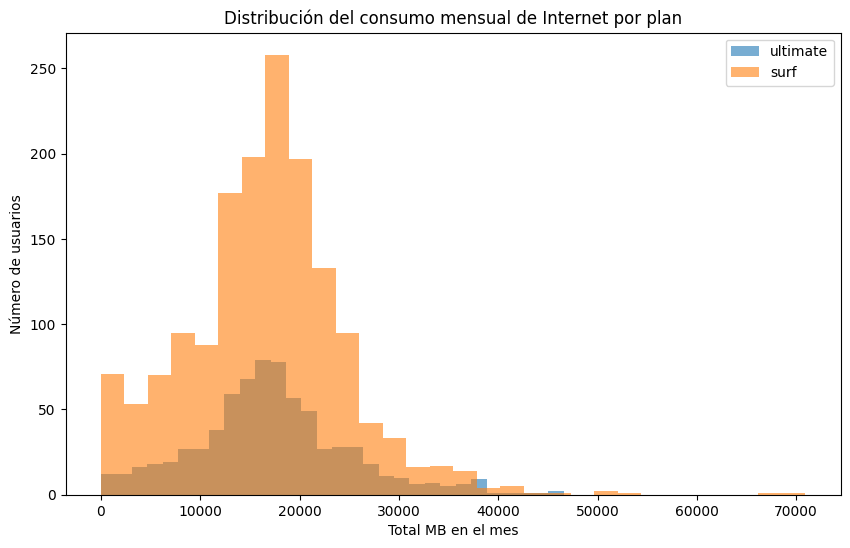

In [41]:
plt.figure(figsize=(10,6))
for plan in usage['plan'].unique():
    subset = usage[usage['plan'] == plan]
    plt.hist(subset['total_mb'], bins=30, alpha=0.6, label=plan)

plt.title("Distribución del consumo mensual de Internet por plan")
plt.xlabel("Total MB en el mes")
plt.ylabel("Número de usuarios")
plt.legend()
plt.show()

<Figure size 800x600 with 0 Axes>

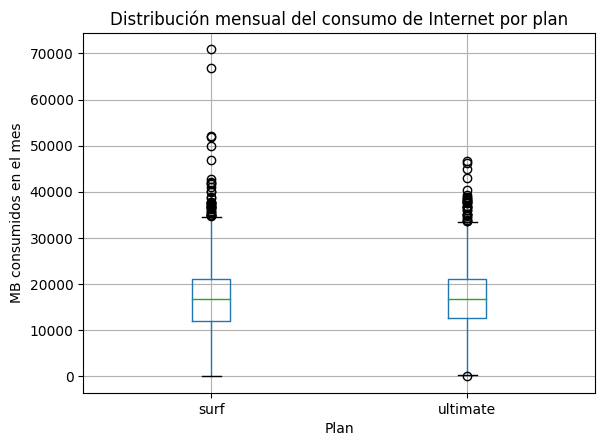

In [42]:
plt.figure(figsize=(8,6))
usage.boxplot(column='total_mb', by='plan')

plt.title("Distribución mensual del consumo de Internet por plan")
plt.suptitle("")
plt.xlabel("Plan")
plt.ylabel("MB consumidos en el mes")
plt.show()


1. Consumo promedio de MB por usuario y mes (barras)

-Tanto Surf como Ultimate muestran una tendencia de crecimiento en el consumo mensual.

-El promedio mensual casi no varía entre planes (15,000–18,000 MB).

-No se observa una diferencia marcada, los dos planes consumen prácticamente lo mismo en promedio.


2. Distribución del consumo mensual (histograma)

-La mayoría de usuarios lso dos planes consumen entre 10,000 y 25,000 MB al mes.

-Surf tiene más usuarios en números absolutos (por eso las barras naranjas son más altas).

-Ultimate, tiene menos usuarios pero su patrón es casi idéntico en la forma de la distribución.


3. Diagrama de caja (boxplot)

-Las medianas de consumo de Surf y Ultimate son muy cercanas (16,000–18,000 MB).

-La dispersión también es parecida, ambos planes tienen muchos outliers con consumos arriba de 40,000 MB (heavy users).

-No hay evidencia de que los usuarios de un plan consuman significativamente más que los del otro.

## Ingreso

In [43]:

stats_ingresos = (
    usage.groupby('plan', as_index=False)
    .agg(media_ingreso=('monthly_revenue','mean'),
         var_ingreso=('monthly_revenue','var'),
         std_ingreso=('monthly_revenue','std'),
         mediana_ingreso=('monthly_revenue','median'))
)

stats_ingresos


,plan,media_ingreso,var_ingreso,std_ingreso,mediana_ingreso
0,surf,60.706408,3067.835152,55.388042,40.36
1,ultimate,72.313889,129.848486,11.395108,70.00


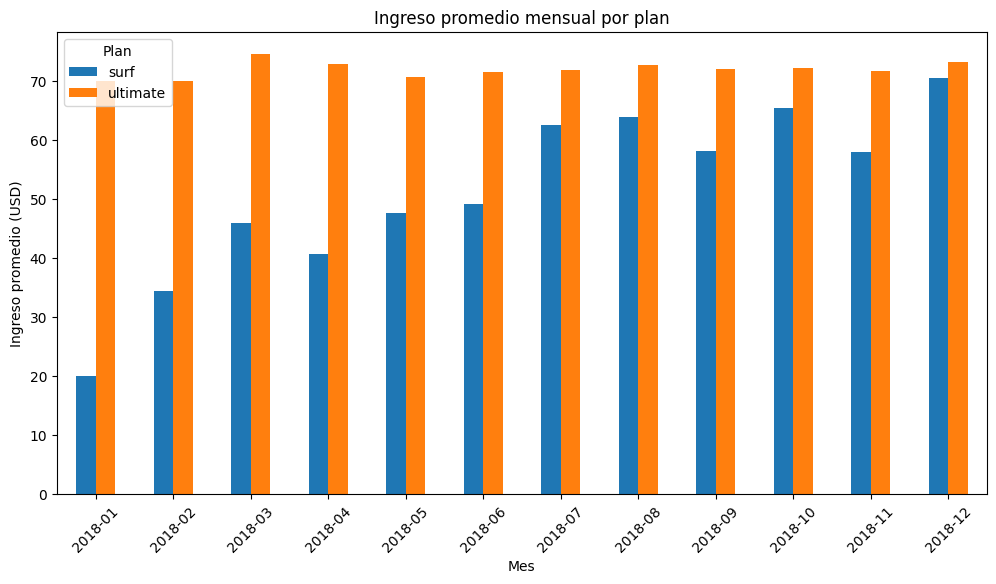

In [44]:
revenue_by_plan = (
    usage.groupby(['plan','month'], as_index=False)
    .agg(avg_revenue=('monthly_revenue','mean'))
)


revenue_pivot = revenue_by_plan.pivot(index='month', columns='plan', values='avg_revenue')


revenue_pivot.plot(kind='bar', figsize=(12,6))
plt.title("Ingreso promedio mensual por plan")
plt.xlabel("Mes")
plt.ylabel("Ingreso promedio (USD)")
plt.legend(title="Plan")
plt.xticks(rotation=45)
plt.show()


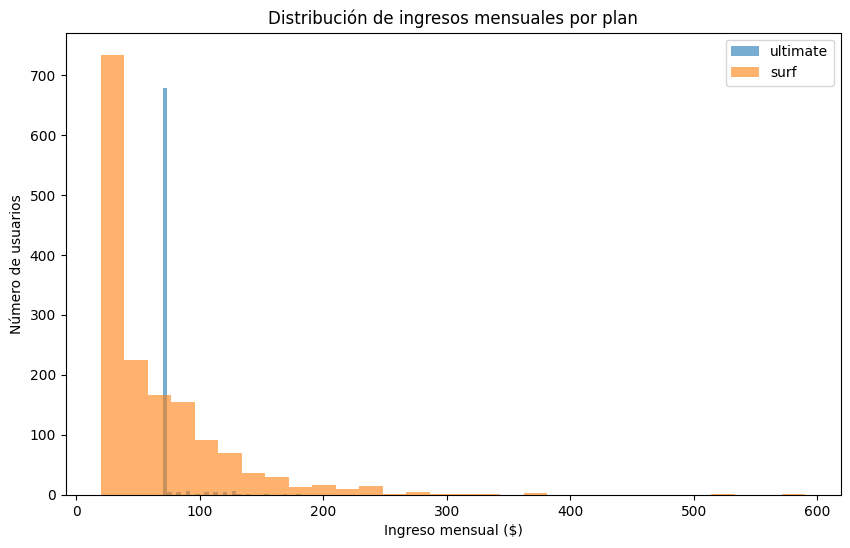

In [45]:

plt.figure(figsize=(10,6))
for plan in usage['plan'].unique():
    subset = usage[usage['plan'] == plan]
    plt.hist(subset['monthly_revenue'], bins=30, alpha=0.6, label=plan)


plt.title("Distribución de ingresos mensuales por plan")
plt.xlabel("Ingreso mensual ($)")
plt.ylabel("Número de usuarios")
plt.legend()
plt.show()


<Figure size 800x600 with 0 Axes>

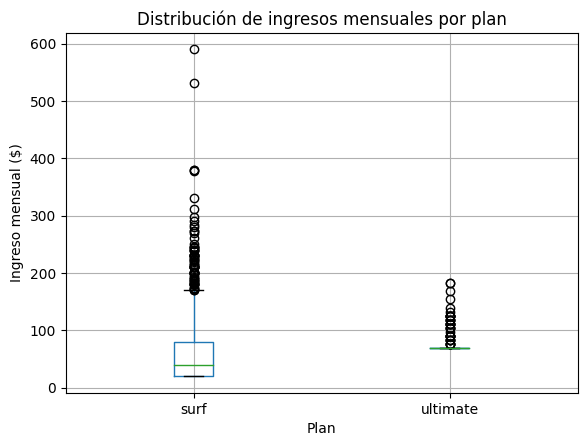

In [46]:

plt.figure(figsize=(8,6))
usage.boxplot(column='monthly_revenue', by='plan')


plt.title("Distribución de ingresos mensuales por plan")
plt.suptitle("")
plt.xlabel("Plan")
plt.ylabel("Ingreso mensual ($)")
plt.show()



Plan Ultimate

-Ingresos estables: La mayoría de usuarios pagan exactamente 70 USD al mes, porque casi nunca sobrepasan los límites incluidos.

-Baja variabilidad: El histograma se concentra en una sola barra y el boxplot muestra una caja casi inexistente, ya que los valores son casi todos iguales.

-Outliers limitados: Solo unos cuantos usuarios pagan más de 70 USD.

-Previsibilidad: Desde el punto de vista de la compañía, este plan ofrece ingresos constantes y predecibles, aunque sin grandes pagos extras.


Plan Surf

-Ingresos variables: Empieza desde una base baja (20 USD mensuales), pero muchos usuarios exceden los límites, elevando los ingresos.

-Gran dispersión: En el histograma los ingresos se distribuyen ampliamente, algunos hasta de 500 USD en casos extremos.

-Mayor riesgo y oportunidad: El boxplot muestra muchos outliers, reflejando usuarios que generan ingresos muy altos para la empresa.

-Ingresos menos predecibles: Aunque algunos meses los usuarios pagan poco, los que sobrepasan mucho los límites compensan, generando picos altos de rentabilidad.

## Prueba las hipótesis estadísticas


Hipótesis

Hipótesis nula (H0):
Los ingresos promedio de los usuarios de los planes Surf y Ultimate son iguales.

Hipótesis alternativa (H1):
Los ingresos promedio de los usuarios de los planes Surf y Ultimate son diferentes.

In [47]:


surf_rev     = usage.loc[usage['plan'] == 'surf', 'monthly_revenue']
ultimate_rev = usage.loc[usage['plan'] == 'ultimate', 'monthly_revenue']


alpha = 0.05


resultado = st.ttest_ind(surf_rev, ultimate_rev, equal_var=False)


print("p-valor:", resultado.pvalue)

print()

if resultado.pvalue < alpha:
    print("Conclusión: Rechazamos H0 → los ingresos promedio SON diferentes entre los planes.")
else:
    print("Conclusión: No rechazamos H0 → no hay evidencia suficiente de diferencia entre planes.")


p-valor: 3.1703905481135734e-15

Conclusión: Rechazamos H0 → los ingresos promedio SON diferentes entre los planes.



Hipótesis

Hipótesis nula (H0):
El ingreso promedio mensual de los usuarios del área NY-NJ es igual al ingreso promedio mensual de los usuarios de otras regiones.

Hipótesis alternativa (H1):
El ingreso promedio mensual de los usuarios del área NY-NJ es diferente al ingreso promedio mensual de los usuarios de otras regiones.

In [48]:
# Prueba las hipótesis

ny_nj_rev   = usage.loc[usage['city'].str.contains('NY-NJ'), 'monthly_revenue']
other_rev   = usage.loc[~usage['city'].str.contains('NY-NJ'), 'monthly_revenue']


alpha = 0.05


resultado = st.ttest_ind(ny_nj_rev, other_rev, equal_var=False)


print("p-valor:", resultado.pvalue)

print()

if resultado.pvalue < alpha:
    print("Conclusión: Rechazamos H0, los ingresos promedio SON diferentes entre NY-NJ y otras regiones.")
else:
    print("Conclusión: No rechazamos H0, no hay evidencia suficiente de diferencia en ingresos entre NY-NJ y otras regiones.")



p-valor: 0.03352561588530014

Conclusión: Rechazamos H0, los ingresos promedio SON diferentes entre NY-NJ y otras regiones.


## Conclusión general


Hallazgos de comportamiento

Llamadas: ambos planes muestran patrón parecido y crecimiento suave durante el año con  medianas muy parecidas.

SMS: uso muy bajo para la mayoría. Surf concentra más usuarios con 0–5 SMS que Ultimate (pico ~500 vs ~190). Diferencias pequeñas en medianas.

Internet: consumo muy similar entre planes; la mayoría está entre 10–25 GB/mes; hay heavy users en ambos.





¿Qué plan genera más ingresos?


Ingreso promedio por usuario:

Ultimate genera un ingreso más alto y estable, prácticamente fijo en 70 USD/mes para la mayoría de los usuarios.

Surf tiene un costo menor (20 USD/mes), pero  tienen muchos clientes que exceden el plan, por lo que la facturación mensual sale mayor.



Variabilidad y dispersión:

En Ultimate, la dispersión es mínima, casi todos los clientes pagan lo mismo. Muy pocos exceden el plan. Por eso en el histograma (pico en 70) y en el boxplot (caja muy aplastada).

En surf los ingresos tienen alta variabilidad porque como el plan incluye poco, suelen pasarse y pagar los extras, hay outliers de entre 100-500 USD, es decir hay clientes que aunque agarran el plan más barato pagan un +400% o hasta un +2400%, más. 


Estabilidad vs. oportunidad:

Ultimate ofrece pagos constantes, la empresa sabe que recibirá aproximadamente 70 USD por cada cliente de este plan, y que muy pocos se pasan de su plan. 

Surf es menos predecible, pero tiene muchos heavy users, que a la larga generan márgenes más grandes gracias a que superan su plan constantemente, en términos de ingreso de cada usuario. 


Estrategia combinada:

Mantener ambos planes

Ultimate asegura un flujo constante de ingresos (seguridad financiera).

Surf permite capturar ingresos extraordinarios de los usuarios que se acaban su plan.

La compañía equilibra estabilidad/ingreso constante (Ultimate) y potencial de crecimiento(gracias a los outliersen Surf).




Perspectiva de negocio

Si la empresa busca cashflow estable y planeación financiera, Ultimate es la opción más sólida.

Si el objetivo es maximizar ingresos por usuario, Surf es más rentable, aunque más volátil.

La publicidad podría segmentarse: 
Ultimate para usuarios que valoran tranquilidad (“todo incluido”), Surf para los que prefieren pagar menos de base pero están dispuestos a cubrir los datos o minutos extras.

Si se trata de dirigir mayor o menor pauta, diría que aumentar los usuarios de Ultimate para generar más cashflow estable y generar fidelización. Ya que se haya visto un crecimiento en el plan Ultimate, ahora pautar con mayor fuerza a Surf para aumentar ingresos por usuario.

















